In [ ]:

options(future.globals.maxSize = 100000000 * 1024^2)

# set random seed for reproducibility
set.seed(12345)

In [ ]:
library(clusterProfiler)
library(org.Hs.eg.db)
library(Seurat)

In [4]:
source('utils.R')
workdir <- "7.WGCNA/"


In [5]:
WGCNA_dir = '7.WGCNA/'
input_rds <-  paste0(WGCNA_dir,'2024_03_28_Myeloid_Metacells_Subclass_ADAM.rds.ztsd')
Metacells <- readCRDS(input_rds)
Metacells$TwoClusters <-  as.vector(Metacells$Clusters)
Metacells$TwoClusters[Metacells$Clusters %in% c("MTC_1","MTC_2","MTC_3")] <- "MTC_123"
Metacells$TwoClusters[Metacells$Clusters %in% c("MTC_4","MTC_5","MTC_6")]<- "MTC_456"


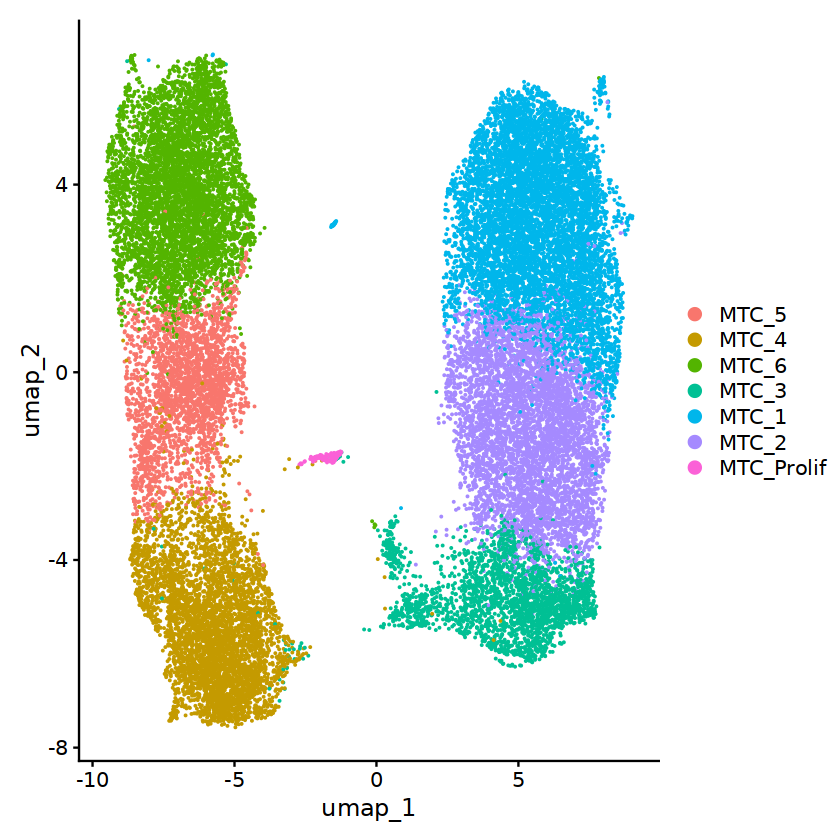

In [6]:
Idents(Metacells)<- 'Clusters'
DimPlot(Metacells)

In [7]:
Metacells_2 <- subset(Metacells,subset=TwoClusters%in%c('MTC_123','MTC_456'))

In [ ]:
New_Metadata <- readr::read_csv('Data/2024_Metadata_ICH.csv')
rownames(New_Metadata) <- New_Metadata$donor
colnames(New_Metadata)

In [9]:
Metacells_2$ICH <- as.numeric(unlist(New_Metadata[Metacells_2$Donor,'ICH Score']))
Metacells_2$mRS_binned <- ifelse(Metacells_2$mRS >=4,'B','G') 
Metacells_2$ICH_binned <- ifelse(Metacells_2$ICH >=4,'B','G') 
Metacells_2$Comb <- paste0("CL_",Metacells_2$TwoClusters,"_ICH_",Metacells_2$ICH_binned,'_mRS_',Metacells_2$mRS_binned)
Metacells_2$Comb2 <- paste0("ICH_",Metacells_2$ICH_binned,'_mRS_',Metacells_2$mRS_binned)


In [34]:
Idents(Metacells_2) <- 'TwoClusters'

In [35]:
deg_pa <- FindAllMarkers(Metacells_2,only.pos = T)

Calculating cluster MTC_456

Calculating cluster MTC_123



In [36]:
significant_Genes <- deg_pa %>% filter(p_val_adj<0.01,avg_log2FC>1.5)

In [ ]:
formula_MF <- compareCluster(gene~cluster, 
                    data=significant_Genes, 
                    fun="enrichGO",
                    OrgDb= org.Hs.eg.db,
                    keyType = "SYMBOL",
                    ont = "MF",
                    pAdjustMethod = "BH", # Adjust p-values using Benjamini & Hochberg method
                    pvalueCutoff = 0.05)

In [ ]:
options(repr.plot.width=7, repr.plot.height=10)
dotplot(formula_MF, showCategory=10)

In [ ]:
pdf('SFigure_3B.pdf',width=7, height=10)
options(repr.plot.width=7, repr.plot.height=10)
dotplot(formula_MF, showCategory=10)
dev.off()

In [39]:
sessionInfo()

R version 4.3.0 (2023-04-21)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Rocky Linux 9.4 (Blue Onyx)

Matrix products: default
BLAS/LAPACK: /sc/arion/work/kyriad02/miniconda3/envs/dreamlet430/lib/libopenblasp-r0.3.23.so;  LAPACK version 3.11.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: America/New_York
tzcode source: system (glibc)

attached base packages:
[1] stats4    stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
 [1] lubridate_1.9.2         forcats_1.0.0           stringr_1.5.0          
 [4] dplyr_1.1.2             purrr_1.0.1             readr_2.1.4            
 [7] tidyr_1.3.0            